In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


sns.set_theme(style="whitegrid")

In [ ]:
## 1. Load and Inspect the Raw Dataset

In this section, I load the dataset and examine its structure, columns, and summary information.

In [4]:
df = pd.read_csv("Covid Data ACTUAL.csv")

df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [10]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nSummary statistics:")
df.describe()

Shape of dataset: (1048575, 21)

Column names:
['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED', 'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT       

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [ ]:
## 2. Filter Confirmed COVID-Positive Patients and Create the Target Variable

In this section, I restrict the dataset to confirmed COVID-positive patients and create a binary mortality outcome called `DEATH`!

In [11]:
covid_df = df[df["CLASIFFICATION_FINAL"].isin([1, 2, 3])].copy()

In [12]:
covid_df["DEATH"] = (covid_df["DATE_DIED"] != "9999-99-99").astype(int)

In [13]:
print("\nDeath value counts:")
print(covid_df["DEATH"].value_counts())

print("\nDeath proportions:")
print(covid_df["DEATH"].value_counts(normalize=True))


Death value counts:
DEATH
0    337743
1     54236
Name: count, dtype: int64

Death proportions:
DEATH
0    0.861635
1    0.138365
Name: proportion, dtype: float64


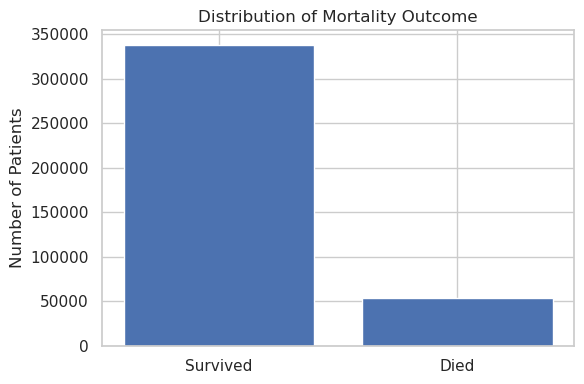

In [14]:
death_counts = covid_df["DEATH"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Survived", "Died"], death_counts.values)
plt.title("Distribution of Mortality Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [ ]:
## 3. Select Predictor Variables

In this section, I choose the demographic and clinical variables that will be used as predictors in the analysis and models.

In [15]:
feature_cols = [
    "SEX",
    "AGE",
    "PNEUMONIA",
    "DIABETES",
    "COPD",
    "ASTHMA",
    "INMSUPR",
    "HIPERTENSION",
    "OTHER_DISEASE",
    "CARDIOVASCULAR",
    "OBESITY",
    "RENAL_CHRONIC",
    "TOBACCO"
]

data = covid_df[feature_cols + ["DEATH"]].copy()

In [ ]:
## 4. Clean Coded Missing Values

In this section, I replace coded placeholder values such as `97`, `98`, and `99` with missing values so they can be handled properly during preprocessing.

In [16]:
data = data.replace({97: np.nan, 98: np.nan, 99: np.nan})

print("Missing values after replacing coded placeholders:\n")
print(data.isnull().sum())

Missing values after replacing coded placeholders:

SEX                  0
AGE                126
PNEUMONIA            4
DIABETES          1440
COPD              1313
ASTHMA            1309
INMSUPR           1449
HIPERTENSION      1388
OTHER_DISEASE     2136
CARDIOVASCULAR    1391
OBESITY           1353
RENAL_CHRONIC     1350
TOBACCO           1434
DEATH                0
dtype: int64


In [ ]:
## 5. Recode Variables into Analysis-Ready Format

In this section, I am converting the binary clinical variables into a cleaner numeric format so they are easier to interpret and use in machine learning.

In [17]:
# Recode SEX: 1 -> 0, 2 -> 1
data["SEX"] = data["SEX"].replace({1: 0, 2: 1})

# Recode binary health condition columns: 1 = yes, 2 = no
binary_cols = [
    "PNEUMONIA",
    "DIABETES",
    "COPD",
    "ASTHMA",
    "INMSUPR",
    "HIPERTENSION",
    "OTHER_DISEASE",
    "CARDIOVASCULAR",
    "OBESITY",
    "RENAL_CHRONIC",
    "TOBACCO"
]

for col in binary_cols:
    data[col] = data[col].replace({1: 1, 2: 0})

In [18]:
print("Unique values after recoding:\n")

for col in feature_cols:
    print(col, sorted(data[col].dropna().unique())[:10])

Unique values after recoding:

SEX [0, 1]
AGE [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
PNEUMONIA [0.0, 1.0]
DIABETES [0.0, 1.0]
COPD [0.0, 1.0]
ASTHMA [0.0, 1.0]
INMSUPR [0.0, 1.0]
HIPERTENSION [0.0, 1.0]
OTHER_DISEASE [0.0, 1.0]
CARDIOVASCULAR [0.0, 1.0]
OBESITY [0.0, 1.0]
RENAL_CHRONIC [0.0, 1.0]
TOBACCO [0.0, 1.0]


In [ ]:
## 6. Create the Cleaned Dataset

In this section, I remove rows with unresolved missing values and create the final cleaned dataset used for visualization and modeling.

In [19]:
clean_data = data.dropna().copy()

print("Shape before dropping missing rows:", data.shape)
print("Shape after dropping missing rows:", clean_data.shape)

display(clean_data.head(10))

Shape before dropping missing rows: (391979, 14)
Shape after dropping missing rows: (388752, 14)


,SEX,AGE,PNEUMONIA,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,DEATH
0,0,65.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
2,1,55.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,1,68.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
5,0,40.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,0,64.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7,0,64.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0
8,0,37.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
9,0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
10,0,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
11,1,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


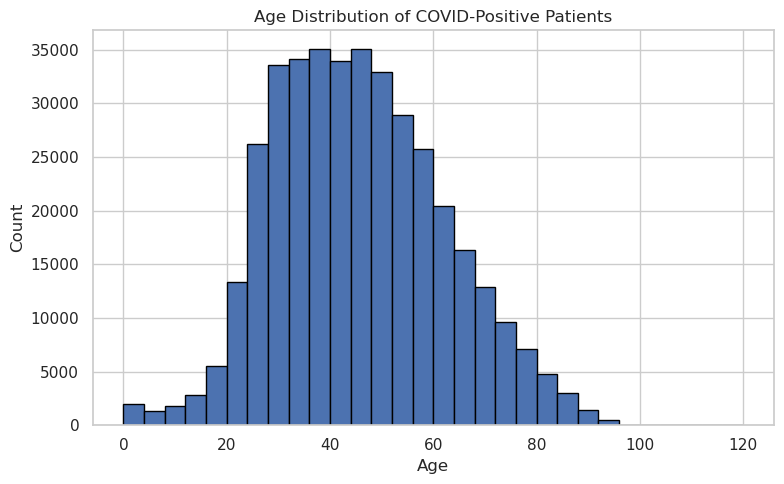

In [20]:
plt.figure(figsize=(8,5))
plt.hist(clean_data["AGE"], bins=30, edgecolor="black")
plt.title("Age Distribution of COVID-Positive Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

AGE_GROUP
0-20     0.015062
21-40    0.024288
41-60    0.132893
61-80    0.395354
80+      0.536955
Name: DEATH, dtype: float64


/tmp/ipykernel_168/232562621.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortality_by_age = clean_data.groupby("AGE_GROUP")["DEATH"].mean()


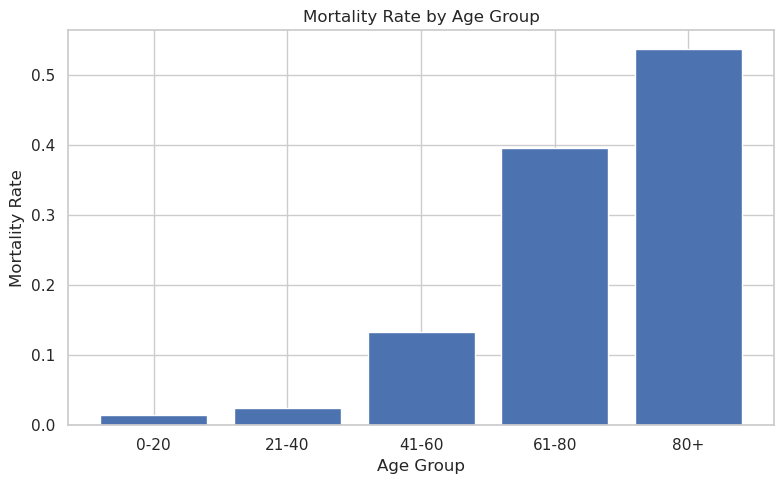

In [21]:
clean_data["AGE_GROUP"] = pd.cut(
    clean_data["AGE"],
    bins=[0, 20, 40, 60, 80, 120],
    labels=["0-20", "21-40", "41-60", "61-80", "80+"],
    include_lowest=True
)

mortality_by_age = clean_data.groupby("AGE_GROUP")["DEATH"].mean()

print(mortality_by_age)

plt.figure(figsize=(8,5))
plt.bar(mortality_by_age.index.astype(str), mortality_by_age.values)
plt.title("Mortality Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mortality Rate")
plt.tight_layout()
plt.show()

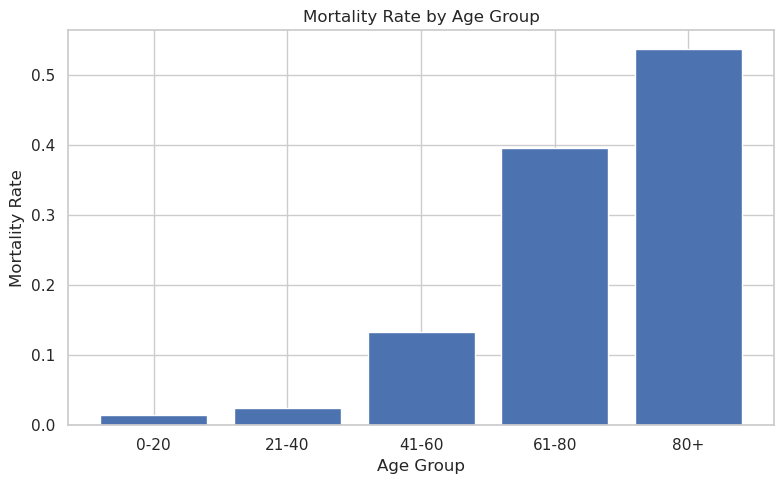

In [22]:
plt.figure(figsize=(8,5))
plt.bar(mortality_by_age.index.astype(str), mortality_by_age.values)
plt.title("Mortality Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mortality Rate")
plt.tight_layout()
plt.savefig("mortality_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

,No,Yes
PNEUMONIA,0.043955,0.471353
DIABETES,0.101595,0.325627
HIPERTENSION,0.097164,0.301102
OBESITY,0.127050,0.181208
RENAL_CHRONIC,0.130698,0.447008


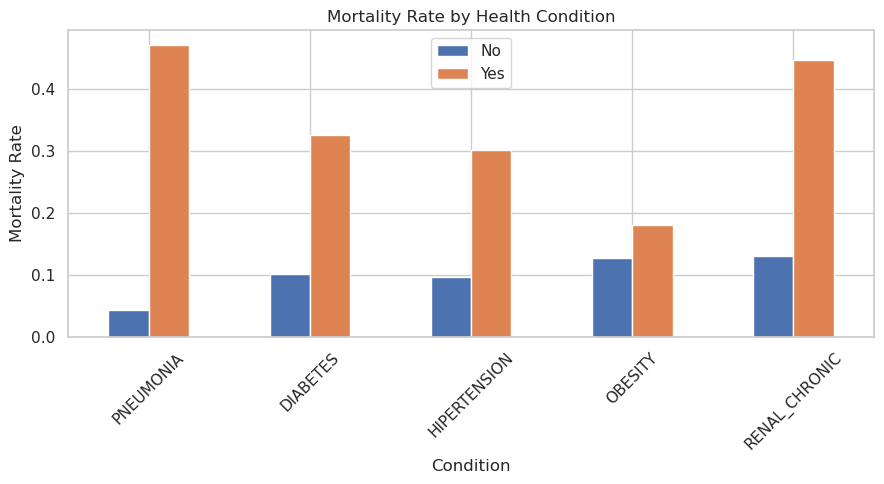

In [25]:
conditions = ["PNEUMONIA", "DIABETES", "HIPERTENSION", "OBESITY", "RENAL_CHRONIC"]

condition_summary = {}

for col in conditions:
    condition_summary[col] = clean_data.groupby(col)["DEATH"].mean()

condition_df = pd.DataFrame({
    col: {
        "No": condition_summary[col].get(0, np.nan),
        "Yes": condition_summary[col].get(1, np.nan)
    }
    for col in conditions
}).T

display(condition_df)

condition_df.plot(kind="bar", figsize=(9,5))
plt.title("Mortality Rate by Health Condition")
plt.xlabel("Condition")
plt.ylabel("Mortality Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## 10. Prepare Data for Modeling

In this section, I prepare the cleaned dataset for machine learning by defining the predictor matrix `X` and target variable `y`.

In [26]:
model_data = clean_data.copy()

# Remove AGE_GROUP because it was created only for visualization
if "AGE_GROUP" in model_data.columns:
    model_data = model_data.drop(columns=["AGE_GROUP"])

sample_size = 50000
if len(model_data) > sample_size:
    model_data = model_data.sample(n=sample_size, random_state=42)

print("Shape of modeling dataset:", model_data.shape)

X = model_data[feature_cols]
y = model_data["DEATH"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Shape of modeling dataset: (50000, 14)
Feature matrix shape: (50000, 13)
Target shape: (50000,)


In [ ]:
## 11. Split the Data into Training and Testing Sets

In this section, I divide the data into training and testing sets so the models can be evaluated on unseen patient records.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (40000, 13)
Test set shape: (10000, 13)

Training set class distribution:
DEATH
0    0.86335
1    0.13665
Name: proportion, dtype: float64

Test set class distribution:
DEATH
0    0.8634
1    0.1366
Name: proportion, dtype: float64


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [29]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Linear SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=5000
        ))
    ])
}

In [30]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8408,0.454582,0.827965,0.586923
1,Linear SVM,0.8391,0.450590,0.811127,0.579346


In [ ]:
## 14. Evaluate the Best Model with a Confusion Matrix

In this section, I examine the best-performing model in more detail using a confusion matrix and classification report.

Best model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      8634
           1       0.45      0.83      0.59      1366

    accuracy                           0.84     10000
   macro avg       0.71      0.84      0.74     10000
weighted avg       0.90      0.84      0.86     10000



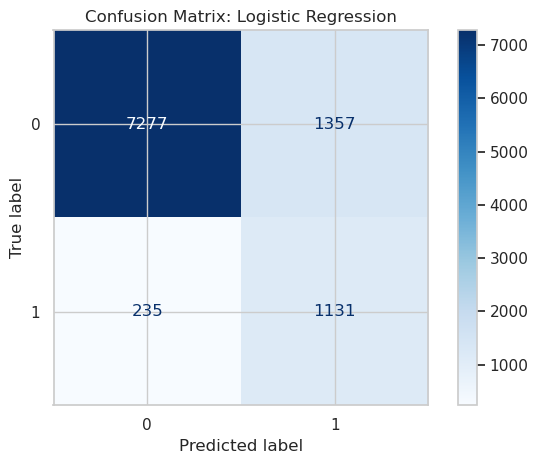

In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

print("Best model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

In [32]:
log_model = models["Logistic Regression"]
log_model.fit(X_train, y_train)

coefficients = log_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

display(coef_df)

,Feature,Coefficient
1,AGE,1.123241
2,PNEUMONIA,1.073081
0,SEX,0.297365
3,DIABETES,0.209202
11,RENAL_CHRONIC,0.145296
10,OBESITY,0.126332
7,HIPERTENSION,0.117467
8,OTHER_DISEASE,0.090606
6,INMSUPR,0.058285
4,COPD,0.011577


In [ ]:
## 15. Interpret Logistic Regression Coefficients

In this section, I examine the Logistic Regression coefficients to identify which variables contributed most strongly to mortality prediction.

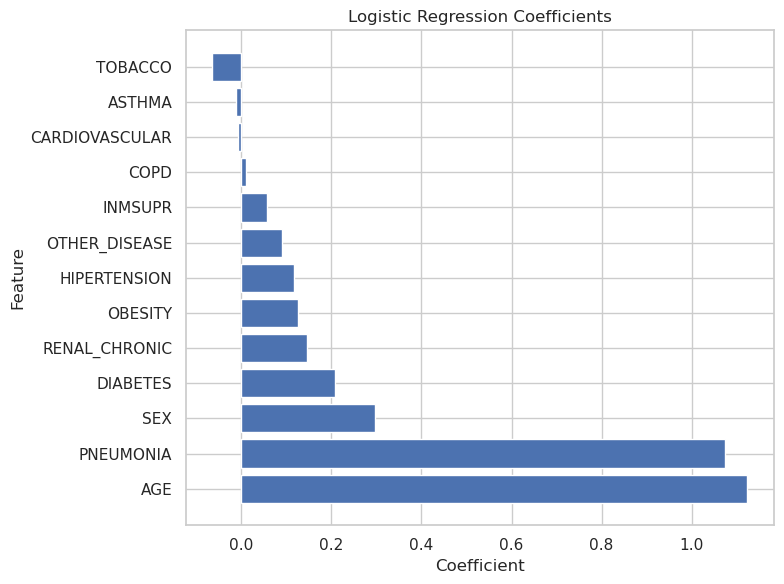

In [33]:
plt.figure(figsize=(8,6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()